In [1]:
import os
import pandas as pd
import numpy as np

# -------------------------------------------------------------
# CONFIGURATION
# -------------------------------------------------------------
TRAINING_DATA_PATH = 'datasets/MODEL_READY_DATASET5.csv'
QLD_VALIDATION_PATH = 'datasets/QLD_MODEL_READY_VALIDATION.csv'
TARGET_COL = 'target_fuel_price_tomorrow'

print("🔍 STARTING QUEENSLAND DATASET MODEL-READY AUDIT...\n" + "="*50)

# 1. FILE EXISTENCE CHECK
if not os.path.exists(QLD_VALIDATION_PATH):
    print(f"❌ CRITICAL ERROR: Validation file not found at '{QLD_VALIDATION_PATH}'")
    print("   Please run your 'qld_merge.py' preprocessing script first.")
    raise SystemExit
else:
    print(f"✅ SUCCESS: Validation file located at '{QLD_VALIDATION_PATH}'")

# Load Validation Data
df_val = pd.read_csv(QLD_VALIDATION_PATH)

# 2. MISSING VALUES ACCOUNTING
total_nans = df_val.isna().sum().sum()
if total_nans > 0:
    print(f"❌ CRITICAL ERROR: Found {total_nans} missing (NaN) values in the dataset!")
    print(df_val.isna().sum()[df_val.isna().sum() > 0])
    print("   Review your ffill()/bfill() or dropna() steps in your merge script.")
else:
    print("✅ SUCCESS: Zero missing (NaN) values detected. Matrix is mathematically complete.")

# 3. METADATA LEAK CHECK
meta_substrings = ['site', 'name', 'brand', 'address', 'suburb', 'state', 'latitude', 'longitude', 'type', 'date', 'region', 'fuelcode']
leaked_cols = [c for c in df_val.columns if any(sub in c.lower() for sub in meta_substrings)]

if leaked_cols:
    print(f"❌ WARNING: String/Metadata columns leaked into the matrix: {leaked_cols}")
    print("   These will cause errors or data leaks during model evaluation!")
else:
    print("✅ SUCCESS: No string tracking metadata headers found. Matrix is fully numerical/boolean.")

# 4. OUTLIER & PLACEHOLDER ANOMALY INSPECTION
if TARGET_COL in df_val.columns:
    max_target = df_val[TARGET_COL].max()
    min_target = df_val[TARGET_COL].min()
    
    if max_target >= 500.0 or min_target <= 50.0:
        print(f"❌ CRITICAL ERROR: Anomalous fuel prices detected in target column!")
        print(f"   Target Max: {max_target}¢/L | Target Min: {min_target}¢/L")
        print("   The '999.9' dummy values or 0.0 entries are leaking into your target variables.")
    else:
        print(f"✅ SUCCESS: Fuel target scales look reasonable (Min: {min_target:.1f}¢/L, Max: {max_target:.1f}¢/L).")
else:
    print(f"❌ CRITICAL ERROR: Target column '{TARGET_COL}' is missing entirely!")

# 5. TRAINING FEATURE ALIGNMENT AUDIT
if os.path.exists(TRAINING_DATA_PATH):
    df_train = pd.read_csv(TRAINING_DATA_PATH)
    train_features = set(df_train.drop(columns=[TARGET_COL], errors='ignore').columns)
    val_features = set(df_val.drop(columns=[TARGET_COL], errors='ignore').columns)
    
    missing_in_val = train_features - val_features
    extra_in_val = val_features - train_features
    
    print("\n--- Structural Alignment Mapping ---")
    print(f"   Features in training data: {len(train_features)}")
    print(f"   Features in validation data: {len(val_features)}")
    
    if missing_in_val:
        print(f"⚠️  WARNING: {len(missing_in_val)} features missing from QLD data that model expects: {list(missing_in_val)}")
        print("   (Your inference script must auto-impute these to 0 before streaming predictions).")
    else:
        print("✅ SUCCESS: All core features required by your trained model are present.")
        
    if extra_in_val:
        print(f"⚠️  NOTE: QLD data contains {len(extra_in_val)} extra columns not used in training: {list(extra_in_val)}")
        print("   (These will be safely ignored or filtered out during feature alignment).")
else:
    print(f"\n⚠️  NOTE: Training file '{TRAINING_DATA_PATH}' not found. Skipping feature structural alignment check.")

# -------------------------------------------------------------
# FINAL VERDICT
# -------------------------------------------------------------
print("="*50)
if total_nans == 0 and not leaked_cols and (TARGET_COL in df_val.columns and df_val[TARGET_COL].max() < 500.0):
    print("🏁 FINAL VERDICT: GREEN LIGHT 🟩")
    print("   The Queensland matrix is fully sanitized, clean, and ready for model inference.")
else:
    print("🏁 FINAL VERDICT: RED LIGHT 🟥")
    print("   Resolve the errors highlighted above before pushing data through the Random Forest.")
print("="*50)

🔍 STARTING QUEENSLAND DATASET MODEL-READY AUDIT...
✅ SUCCESS: Validation file located at 'datasets/QLD_MODEL_READY_VALIDATION.csv'
✅ SUCCESS: Zero missing (NaN) values detected. Matrix is mathematically complete.
✅ SUCCESS: No string tracking metadata headers found. Matrix is fully numerical/boolean.
✅ SUCCESS: Fuel target scales look reasonable (Min: 147.6¢/L, Max: 213.9¢/L).

--- Structural Alignment Mapping ---
   Features in training data: 26
   Features in validation data: 26
✅ SUCCESS: All core features required by your trained model are present.
🏁 FINAL VERDICT: GREEN LIGHT 🟩
   The Queensland matrix is fully sanitized, clean, and ready for model inference.


Step 1: Loading historical training data to fit production model...

Step 2: Loading Queensland validation data and structural alignment...
Step 3: Streaming QLD dataset through Random Forest model...

   QUEENSLAND OUT-OF-SAMPLE VALIDATION PERFORMANCE
QLD Validation MAE:  2.9505 cents
QLD Validation RMSE: 5.1588 cents
QLD Validation R²:   0.9189


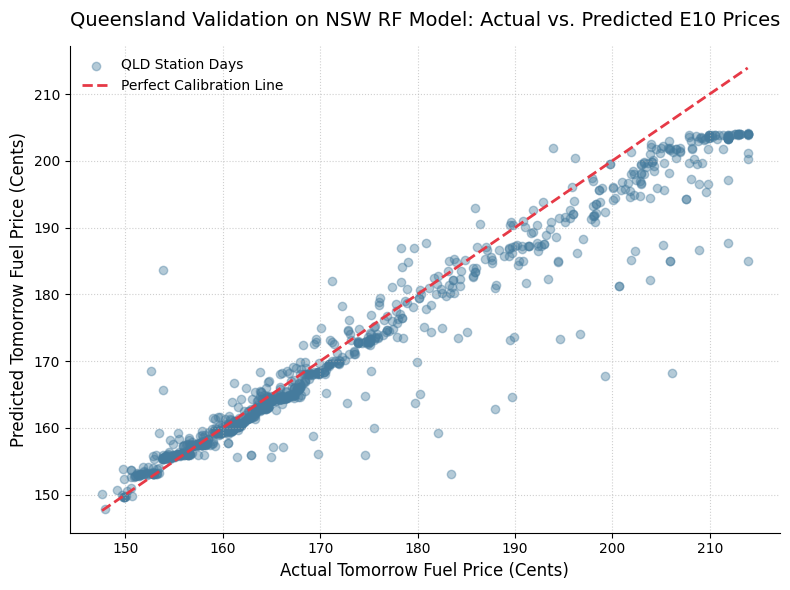

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------------------------------------------
# 1. FILE SYSTEM ROUTING PATHS
# -------------------------------------------------------------
MODEL_READY_DATASET = 'datasets/MODEL_READY_DATASET5.csv'      # Your original training dataset
QLD_VALIDATION_DATASET = 'datasets/QLD_MODEL_READY_VALIDATION.csv'  # Your new QLD dataset

# -------------------------------------------------------------
# 2. LOAD ORIGINAL DATA TO TRAIN THE PRODUCTION MODEL
# -------------------------------------------------------------
print("Step 1: Loading historical training data to fit production model...")
df_train = pd.read_csv(MODEL_READY_DATASET)

target_col = 'target_fuel_price_tomorrow'
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]

# Train the Random Forest using your optimal hyperparameters
from sklearn.ensemble import RandomForestRegressor
rf_production_model = RandomForestRegressor(
    n_estimators=300, 
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=30,
    max_features=0.6,
    bootstrap=True,
    random_state=42, 
    n_jobs=-1
)
rf_production_model.fit(X_train, y_train)

# -------------------------------------------------------------
# 3. LOAD AND ALIGN THE QUEENSLAND VALIDATION DATA
# -------------------------------------------------------------
print("\nStep 2: Loading Queensland validation data and structural alignment...")
df_qld = pd.read_csv(QLD_VALIDATION_DATASET)

# Separate the QLD target column
y_qld_actual = df_qld[target_col]
X_qld_raw = df_qld.drop(columns=[target_col])

# CRITICAL STEP: Align validation columns perfectly with original feature structures
missing_cols = set(X_train.columns) - set(X_qld_raw.columns)
for col in missing_cols:
    X_qld_raw[col] = 0  # Impute 0 for columns present in training but missing in QLD

# Reorder columns to match original layout precisely and filter out unexpected extras
X_qld_aligned = X_qld_raw[X_train.columns]

# -------------------------------------------------------------
# 4. GENERATE QUEENSLAND PREDICTIONS
# -------------------------------------------------------------
print("Step 3: Streaming QLD dataset through Random Forest model...")
qld_preds = rf_production_model.predict(X_qld_aligned)

# -------------------------------------------------------------
# 5. EVALUATE OUT-OF-SAMPLE PERFORMANCE
# -------------------------------------------------------------
qld_mae = mean_absolute_error(y_qld_actual, qld_preds)
qld_rmse = np.sqrt(mean_squared_error(y_qld_actual, qld_preds))
qld_r2 = r2_score(y_qld_actual, qld_preds)

print("\n" + "="*60)
print("   QUEENSLAND OUT-OF-SAMPLE VALIDATION PERFORMANCE")
print("="*60)
print(f"QLD Validation MAE:  {qld_mae:.4f} cents")
print(f"QLD Validation RMSE: {qld_rmse:.4f} cents")
print(f"QLD Validation R²:   {qld_r2:.4f}")
print("="*60)

# -------------------------------------------------------------
# 6. VISUALIZE MODEL CALIBRATION (ACTUAL VS. PREDICTED)
# -------------------------------------------------------------
plt.figure(figsize=(8, 6))

# Sample 1000 data points if dataset is massive for clean scannability
sample_size = min(1000, len(y_qld_actual))
sample_indices = np.random.choice(len(y_qld_actual), sample_size, replace=False)

plt.scatter(y_qld_actual.iloc[sample_indices], qld_preds[sample_indices], 
            alpha=0.4, color='#457B9D', label='QLD Station Days')

# Identity line representing perfect predictions
ideal_min = min(y_qld_actual.min(), qld_preds.min())
ideal_max = max(y_qld_actual.max(), qld_preds.max())
plt.plot([ideal_min, ideal_max], [ideal_min, ideal_max], 
         color='#E63946', linestyle='--', linewidth=2, label='Perfect Calibration Line')

plt.title('Queensland Validation on NSW RF Model: Actual vs. Predicted E10 Prices', fontsize=14, pad=15)
plt.xlabel('Actual Tomorrow Fuel Price (Cents)', fontsize=12)
plt.ylabel('Predicted Tomorrow Fuel Price (Cents)', fontsize=12)
plt.legend(frameon=False, loc='upper left')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

⏳ Loading matrices and fitting Linear Regression model...

📊 LINEAR REGRESSION QUEENSLAND RESULTS:
   Mean Absolute Error (MAE): 2.76 cents
   R-squared Coefficient (R²): 0.9315


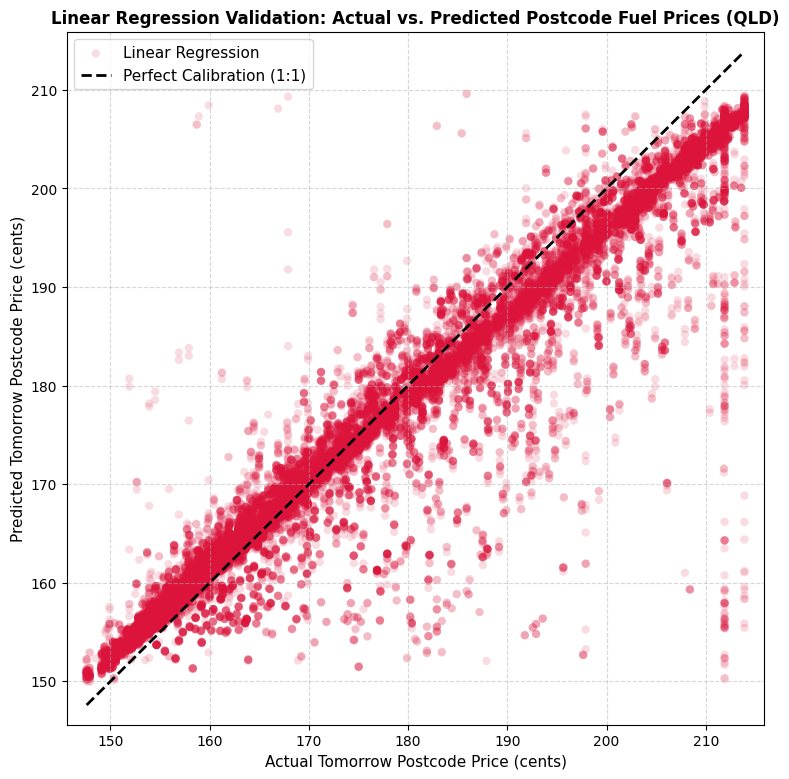

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# -------------------------------------------------------------
# CONFIGURATION & INGESTION
# -------------------------------------------------------------
TRAINING_DATA_PATH = 'datasets/MODEL_READY_DATASET5.csv'
QLD_VALIDATION_PATH = 'datasets/QLD_MODEL_READY_VALIDATION.csv'
TARGET_COL = 'target_fuel_price_tomorrow'

print("⏳ Loading matrices and fitting Linear Regression model...")

# Load datasets
df_train = pd.read_csv(TRAINING_DATA_PATH)
df_qld = pd.read_csv(QLD_VALIDATION_PATH)

# Extract features and targets
X_train = df_train.drop(columns=[TARGET_COL])
y_train = df_train[TARGET_COL]

X_qld = df_qld.drop(columns=[TARGET_COL])
y_qld = df_qld[TARGET_COL]

# -------------------------------------------------------------
# FEATURE SCALING (Mandatory for Linear Regression)
# -------------------------------------------------------------
# Linear models require scaled inputs to maintain numerical stability 
# and properly interpret coefficient gradients without scale-bias.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_qld_scaled = scaler.transform(X_qld)

# -------------------------------------------------------------
# MODEL EXECUTION & PREDICTION
# -------------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Generate predictions for Queensland validation window
qld_preds_lr = lr_model.predict(X_qld_scaled)

# -------------------------------------------------------------
# METRIC EVALUATION
# -------------------------------------------------------------
mae_lr = mean_absolute_error(y_qld, qld_preds_lr)
r2_lr = r2_score(y_qld, qld_preds_lr)

print("\n" + "="*50)
print(f"📊 LINEAR REGRESSION QUEENSLAND RESULTS:")
print(f"   Mean Absolute Error (MAE): {mae_lr:.2f} cents")
print(f"   R-squared Coefficient (R²): {r2_lr:.4f}")
print("="*50)

# -------------------------------------------------------------
# SCATTER PLOT VISUALIZATION
# -------------------------------------------------------------
plt.figure(figsize=(9, 9))

# Scatter plot of actual vs predicted values
plt.scatter(y_qld, qld_preds_lr, alpha=0.15, color='crimson', edgecolors='none', label='Linear Regression')

# 1:1 Reference Line demonstrating perfect calibration
min_val = min(y_qld.min(), qld_preds_lr.min())
max_val = max(y_qld.max(), qld_preds_lr.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Calibration (1:1)')

# Labeling and styling
plt.title('Linear Regression Validation: Actual vs. Predicted Postcode Fuel Prices (QLD)', fontsize=12, fontweight='bold')
plt.xlabel('Actual Tomorrow Postcode Price (cents)', fontsize=11)
plt.ylabel('Predicted Tomorrow Postcode Price (cents)', fontsize=11)
plt.xlim(min_val - 2, max_val + 2)
plt.ylim(min_val - 2, max_val + 2)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [4]:
# -------------------------------------------------------------
# 1. ALIGN COLUMNS AND RUN INFERENCE ON QUEENSLAND DATA
# -------------------------------------------------------------
# 1. On-the-fly fix: create the legacy columns if they are missing from df_val
if 'post_avg' not in df_val.columns:
    df_val['post_avg'] = df_val['fuel_postcode_daily_avg']
if 'post_roll_7' not in df_val.columns:
    df_val['post_roll_7'] = df_val['fuel_postcode_rolling_7d']

# 2. Isolate features and target from your QLD validation matrix
X_qld = df_val.drop(columns=['target_fuel_price_tomorrow'])
y_qld = df_val['target_fuel_price_tomorrow']

# 3. CRITICAL FIX: Reorder QLD features to match the exact schema the models/scaler expect
# (If X_train is not in memory from an earlier cell, use: pd.read_csv('datasets/MODEL_READY_DATASET5.csv', nrows=0).drop(columns=['target_fuel_price_tomorrow']).columns)
expected_columns = X_train.columns if 'X_train' in locals() else pd.read_csv('datasets/MODEL_READY_DATASET5.csv', nrows=0).drop(columns=['target_fuel_price_tomorrow']).columns
X_qld = X_qld[expected_columns]

# 4. Scale features for the Linear Regression model safely
X_qld_scaled = scaler.transform(X_qld)

# 5. Generate predictions from both architectures
qld_rf_preds = rf_production_model.predict(X_qld)
qld_lr_preds = lr_model.predict(X_qld_scaled)

# -------------------------------------------------------------
# 2. RECONSTRUCT THE TIMELINE WITH DATES FROM MEMORY
# -------------------------------------------------------------
# Using df_final index alignment to map dates back to df_val rows
comparison_qld_df = pd.DataFrame({
    'date': pd.to_datetime(df_final.loc[df_val.index, 'date']),
    'postcode': X_qld['postcode'],
    'actual': y_qld,
    'rf_pred': qld_rf_preds,
    'lr_pred': qld_lr_preds
})

# -------------------------------------------------------------
# 3. SELECT A SAMPLE POSTCODE & SORT
# -------------------------------------------------------------
sample_qld_postcode = comparison_qld_df['postcode'].mode()[0]
plot_qld_data = comparison_qld_df[comparison_qld_df['postcode'] == sample_qld_postcode].sort_values('date')

# -------------------------------------------------------------
# 4. CREATE THE COMPARISON PLOT
# -------------------------------------------------------------
plt.figure(figsize=(15, 8))

# Actual price line
plt.plot(plot_qld_data['date'], plot_qld_data['actual'], 
         label='Actual Tomorrow Price (Postcode Avg)', color='black', lw=2.5, linestyle='-', alpha=0.9)

# Random Forest prediction line
plt.plot(plot_qld_data['date'], plot_qld_data['rf_pred'], 
         label='RF Prediction', color='#1f77b4', linestyle='--', alpha=0.8, lw=2)

# Linear Regression prediction line
plt.plot(plot_qld_data['date'], plot_qld_data['lr_pred'], 
         label='LR Prediction', color='#ff7f0e', linestyle='--', alpha=0.8, lw=2)

plt.title(f'Queensland Validation: Absolute Price Prediction Timeline (RF vs LR - Postcode {int(sample_qld_postcode)})', fontsize=14, fontweight='bold')
plt.ylabel('Price (Cents)', fontsize=12)
plt.xlabel('Timeline (Jan - Feb 2026)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'df_final' is not defined